# 🏢 Apartment value radar
## Summary
**Objective:** Analyze the key price drivers in the Polish housing market and develop a predictive model to identify undervalued properties and find market bargains.

**Dataset:** over 100k real estate records from 15 largest Polish cities.

**Model:** **XGBRegressor** embedded in a scikit-learn Pipeline, optimized using **Optuna**.

**Results:** The model achieved a highly accurate **MAPE** of 8.31% (**MAE** of 63,200 PLN) on the test data. 

**Dashboard:** A comprehensive **Microsoft Power BI** report designed to visualize market trends and easily filter out the best investment opportunities.

# 📥 Data loading
Full dataset is extensive. It cointains apartments for rent as well as for sale. In this project, my goal is to analyze the price of apartments for sell only. In fact, I consolidate all parts of the data that cointains only these type of offers.

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import duckdb
warnings.filterwarnings('ignore')
path_sell = '/kaggle/input/datasets/krzysztofjamroz/apartment-prices-in-poland/apartments_pl_*.csv'
data = duckdb.query(f"SELECT * FROM read_csv_auto('{path_sell}')").df()

## Initial exploartion & Features selection
I begin by handling duplicates, identifying missing data patterns and standardizing data types. I also examine the target variable's distribution to detect potential anomalies. Subsequently, I perform a train test split to ensure that further preprocessing, such as missing value imputation, is conducted without data leakage.

### Duplicates

Data collected from several sources often contains duplicate records due to cross listing by sellers. Identifying and removing these overlaps is crucial.

In [2]:
print(f'Initial number of records: {len(data)}')
data=data.drop_duplicates()
data=data.drop('id',axis=1)
print(f'Number of records after removing duplicates: {len(data)}')

Initial number of records: 195568
Number of records after removing duplicates: 111968


full dataset
All rows: 111968
                      Count  Fraction
condition             83711  0.747633
buildingMaterial      46227  0.412859
type                  23356  0.208595
floor                 19394  0.173210
buildYear             18260  0.163082
hasElevator            5245  0.046844
collegeDistance        3062  0.027347
floorCount             1255  0.011209
clinicDistance          395  0.003528
restaurantDistance      263  0.002349
pharmacyDistance        147  0.001313
postOfficeDistance      125  0.001116
kindergartenDistance    101  0.000902
schoolDistance           76  0.000679


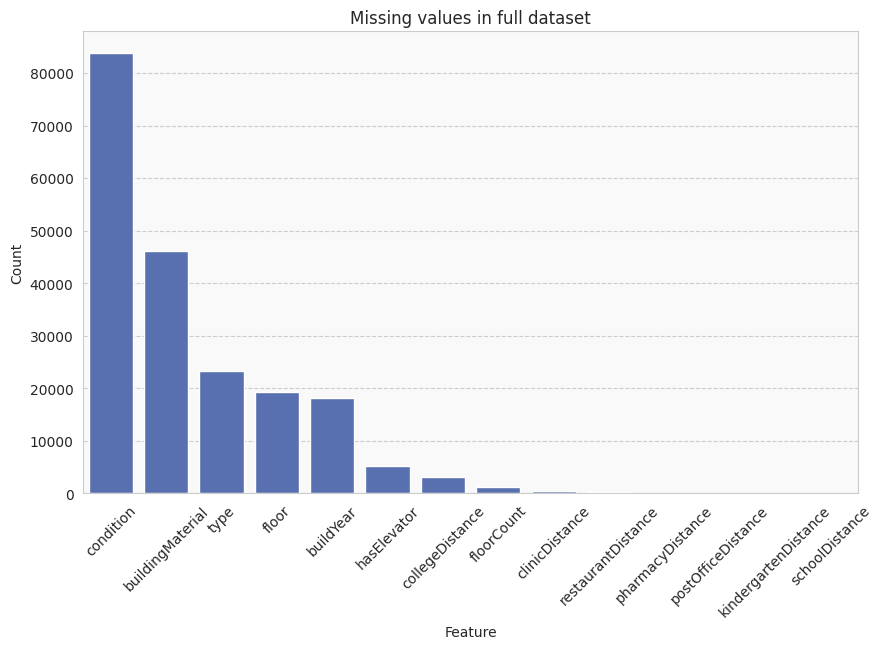

All columns: Index(['city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition',
       'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
       'hasStorageRoom', 'price'],
      dtype='object')


In [3]:
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.6,"axes.facecolor": "#f9f9f9",
    "figure.facecolor": "white"})
color="#4a69bd"
def analyze_missing(df, name=""):
    missing = df.isnull().sum().sort_values(ascending=False)
    missing_df = pd.DataFrame(missing).rename(columns={0: 'Count'})
    missing_df = missing_df[missing_df['Count'] >0]
    missing_df['Fraction'] = missing_df['Count']/len(df)
    
    print(f'{name}')
    print(f'All rows: {len(df)}')
    print(missing_df)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=missing_df, x=missing_df.index, y='Count', color="#4a69bd",edgecolor='white')
    plt.title(f'Missing values in {name}')
    plt.xlabel('Feature')
    plt.tick_params(axis='x',rotation=45)
    plt.show()
analyze_missing(data,'full dataset');
print(f'All columns: {data.columns}')

**Observation & strategy:**
* **Distance columns:** Since the dataset already contains information about `city` and `centerDistance`, I discard the numerous other `[...]Distance` features as well as `poiCount`. This not only reduces multicollinearity within the model but also prevents cluttering the final Power BI dashboard.

*  **`condition`:** Despite 75% missing data in this column, I preserve it based on domain knowledge as it may have  high impact on valuation. I imput missing entries as a **'standard'** category.
*  **Remaining:** Mostly median/mode calculated from the train set. I will also attempt smart imputation.

In [4]:
data = data.drop(columns = ['schoolDistance','clinicDistance','postOfficeDistance','kindergartenDistance', 
                            'restaurantDistance', 'collegeDistance','pharmacyDistance','poiCount'],axis=1)
data['condition'].fillna('standard',inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 111968 entries, 0 to 195557
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   city              111968 non-null  object 
 1   type              88612 non-null   object 
 2   squareMeters      111968 non-null  float64
 3   rooms             111968 non-null  float64
 4   floor             92574 non-null   float64
 5   floorCount        110713 non-null  float64
 6   buildYear         93708 non-null   float64
 7   latitude          111968 non-null  float64
 8   longitude         111968 non-null  float64
 9   centreDistance    111968 non-null  float64
 10  ownership         111968 non-null  object 
 11  buildingMaterial  65741 non-null   object 
 12  condition         111968 non-null  object 
 13  hasParkingSpace   111968 non-null  bool   
 14  hasBalcony        111968 non-null  bool   
 15  hasElevator       106723 non-null  boolean
 16  hasSecurity       111968 

### Data types
I convert boolean flags to binary integers 0/1.

In [5]:
bool_cols = ['hasParkingSpace','hasBalcony','hasElevator','hasSecurity','hasStorageRoom']
data[bool_cols] = data[bool_cols].astype('Int8')

### Target (price)

<Axes: xlabel='price', ylabel='Count'>

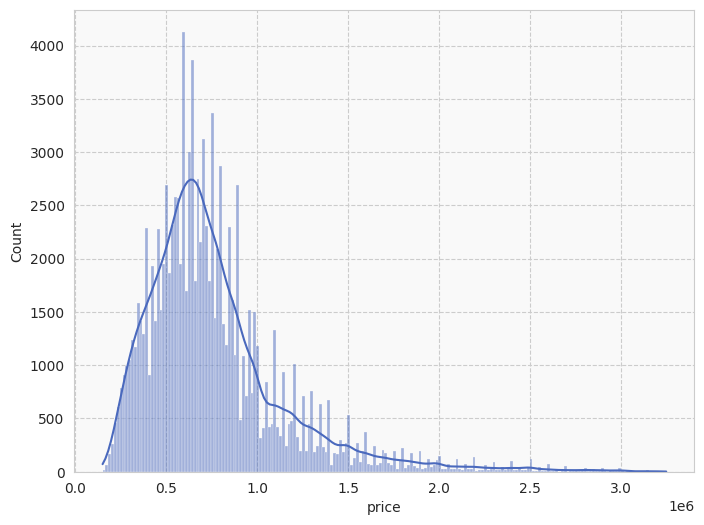

In [6]:
plt.figure(figsize=(8,6))
sns.histplot(data,x='price',kde=True,color=color)

**Observation:** The target variable `price` is highly right-skewed. I will apply a log transformation to the target variable during the modeling phase to normalize the distribution which may improve model performance.

In [7]:
print('Sample of data to ensure that everything went correct:')
data.head()

Sample of data to ensure that everything went correct:


,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,6.53,condominium,concreteSlab,standard,1,1,1,0,1,415000
1,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,2.15,cooperative,concreteSlab,standard,0,1,1,0,1,395995
2,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,3.24,condominium,brick,standard,0,0,0,0,0,565000
3,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,2.27,condominium,brick,standard,1,1,0,0,1,640000
4,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,4.07,condominium,None,standard,0,0,0,0,0,759000


**Note:** During the **exploatory data analysis** shown later in the notebook, I discovered a statistically insignificant category called "udział" (fractional share) in the ownership column. To prevent these records from distorting the apartment prices, I remove them here.

Additionally, I renamed "warszawa" to "warsaw" to maintain language consistency across the project.

In [8]:
print(f'Records removed: {len(data.loc[data['ownership'] == 'udział'])}')
data = data.loc[data['ownership'] != 'udział']
data['city'] = data['city'].replace({'warszawa': 'warsaw'})

Records removed: 8


# ✂️ Train test split

I perform a 90:10 data split. Then I combine X_train with y_train into one data frame called train only for analysis and visualization.

In [9]:
from sklearn.model_selection import train_test_split
y = data['price']
X = data.drop('price',axis=1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=10)
train = pd.concat([X_train,y_train],axis=1)
X_train.drop(columns=['latitude','longitude'],inplace=True)
X_test.drop(columns=['latitude','longitude'],inplace=True)


# 🧹 Data cleaning

I begin by verifying data types and outliers. After, I check the missing value distribution across both the training and testing sets to ensure a representative split. Following this, I conduct analysis of the training set to establish logical relationships between features which allows me to decide cleaning strategy. 

**Note:** I follow a step by step transformation process for the training set, documented with markdown cells for clarity. Later, I consolidate these steps into a single function. This function is then applied to the test set.

train set
All rows: 100764
                  Count  Fraction
buildingMaterial  41534  0.412191
type              21008  0.208487
floor             17483  0.173504
buildYear         16464  0.163392
hasElevator        4730  0.046941
floorCount         1127  0.011185


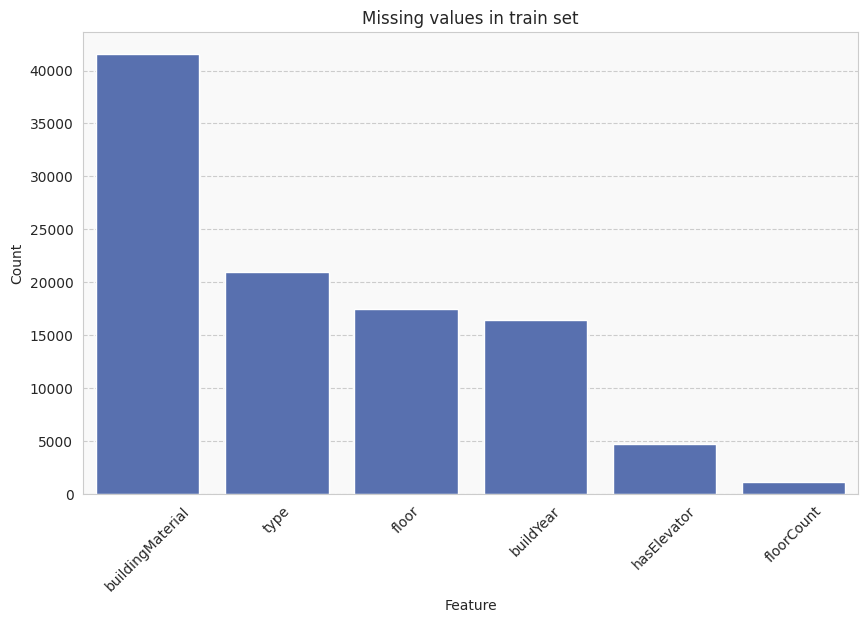

test set
All rows: 11196
                  Count  Fraction
buildingMaterial   4693  0.419168
type               2348  0.209718
floor              1910  0.170597
buildYear          1794  0.160236
hasElevator         515  0.045999
floorCount          128  0.011433


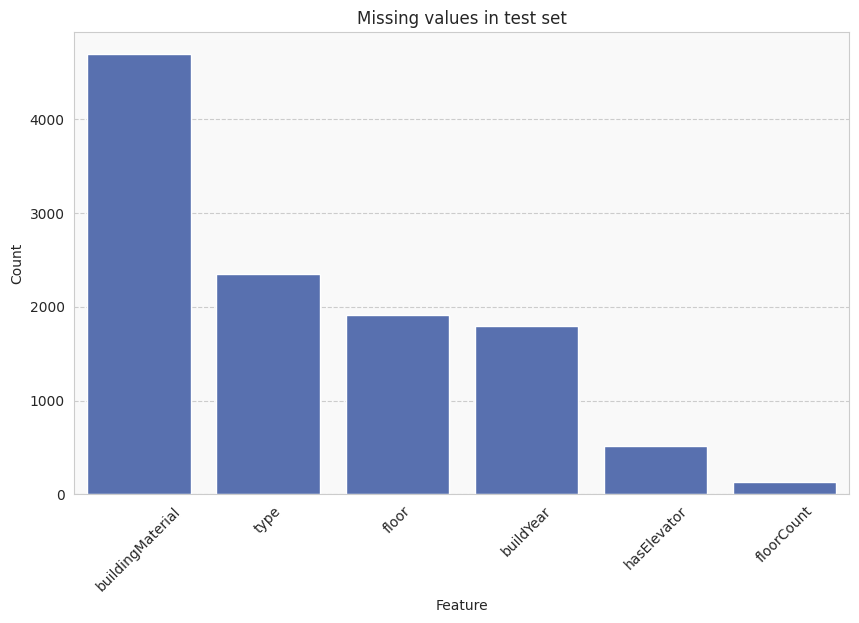

In [10]:
analyze_missing(train,'train set')
analyze_missing(X_test,'test set')

## `floorCount`,`buildYear`
Here I apply median imputation to these features as it is robust against outliers. Additionally, I perform a logical check for floorCount: if the assigned floor of apartment is higher than the building's total floorCount, I adjust the floorCount to match the floor. This prevnts "nonsense" records.

In [11]:
for col in ['floorCount','buildYear']:
    imput_value = train[col].median()
    train[col] = train[col].fillna(imput_value)
train['floorCount'] = train[['floor', 'floorCount']].max(axis=1)

## `hasElevator`

Based on Polish construction standards, residential buildings taller than four floors constructed after 1980 are typically equipped with elevators.


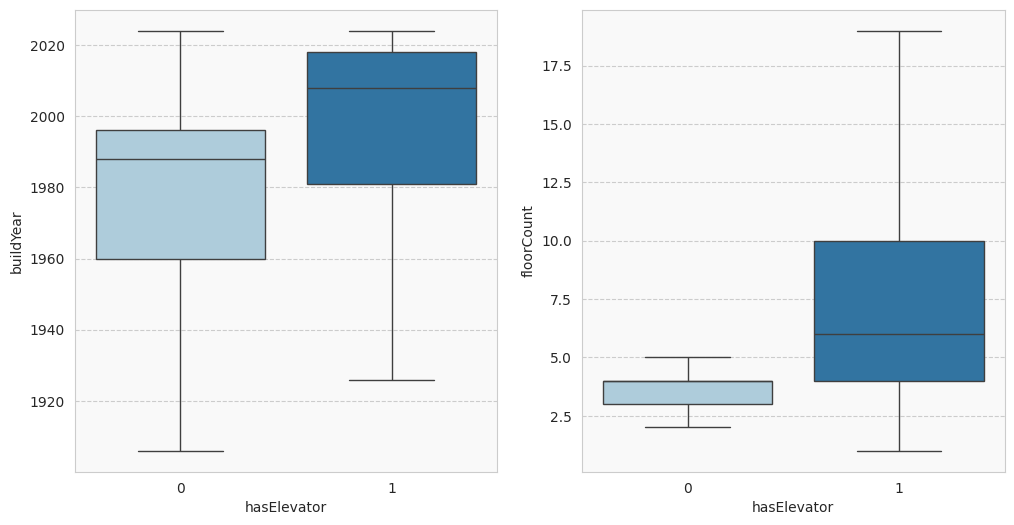

In [12]:
fig,axes=plt.subplots(1,2,figsize=(12,6))
sns.boxplot(data=train.dropna(subset=['buildYear', 'hasElevator']), x='hasElevator', y='buildYear',palette='Paired',
            showfliers=False,ax=axes[0])
sns.boxplot(data=train.dropna(subset=['floorCount', 'hasElevator']), x='hasElevator', y='floorCount',palette='Paired',
            showfliers=False,ax=axes[1])
plt.show()
mask_elevator = (train['buildYear']>= 1980) & (train['floorCount'] >= 5)
train['hasElevator'] = train['hasElevator'].fillna(mask_elevator.astype('Int8'))

## `floor`

I apply median value based on the max floor the building has. 

In [13]:
floor_median=train.groupby('floorCount')['floor'].median()
train['floor'] = train['floor'].fillna(train['floorCount'].map(floor_median))

## `type`

In the Polish housing market, building type is historically determined by the era of construction. Imput strategy:

**tenement:**   <1960

**blockOFFlats**:  (1960-2010)

**apartmentBuilding**:  >2010

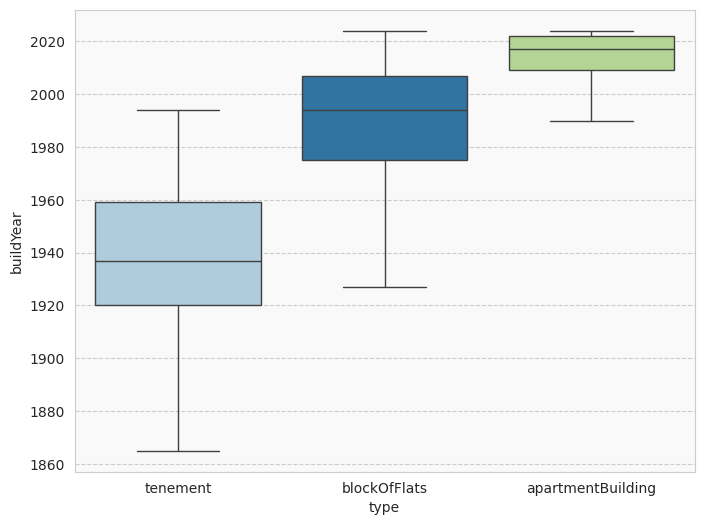

In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(train,y='buildYear',x='type',showfliers=False,palette='Paired',order=['tenement','blockOfFlats','apartmentBuilding'])

def fill_type(row):
    if pd.isnull(row['type']):
        year = row['buildYear']
        if year < 1960:
            return 'tenement'
        elif year <2010:
            return 'blockOfFlats'
        else: 
            return 'apartmentBuilding'
    else:
        return row['type']
    
train['type'] = train.apply(fill_type,axis=1)

## `buildingMaterial`

Building material strongly depends on time when apartment was built and also from its type.

Imputation Logic: Based on these insights, I implement this rule-based function:

**brick**: assigned to all tenements, pre-1970 structures, and modern developments.

**concreteSlab**: targeted specifically at blocks of flats built between (1970–1990)

buildingMaterial  type             
brick             apartmentBuilding    17125
                  tenement             13979
                  blockOfFlats         13703
concreteSlab      blockOfFlats         14276
                  apartmentBuilding      125
                  tenement                22
Name: count, dtype: int64


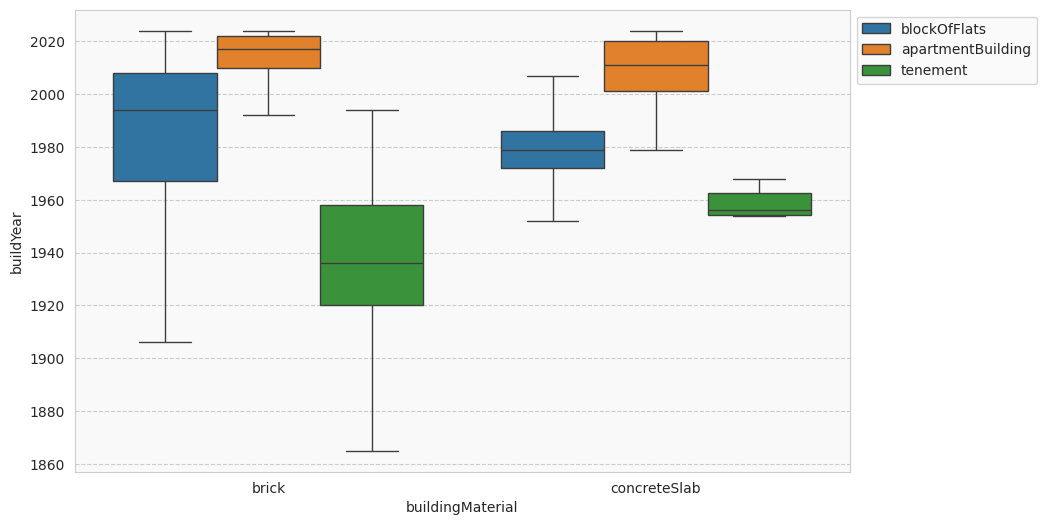

In [15]:
print(train.groupby('buildingMaterial')['type'].value_counts())
plt.figure(figsize=(10,6))
sns.boxplot(train,y='buildYear',x='buildingMaterial',showfliers=False,hue='type')
plt.legend(bbox_to_anchor=[1,1])

def fill_material(row):
    if pd.isnull(row['buildingMaterial']):
        
        year = row['buildYear']
        b_type = row['type']
        if pd.isnull(year) or pd.isnull(b_type):
            return 'brick'
        
        if b_type == 'tenement':
            return 'brick'
        
        if year <1970:
            return 'brick'
        
        if b_type == 'blockOfFlats' and 1970<= year <=  1990:
            return 'concreteSlab'
        if year > 1990:
            return 'brick'
        
        return 'brick'
    else:
        return row['buildingMaterial']


train['buildingMaterial'] = train.apply(fill_material, axis=1)
        
        

In [16]:
print(train.isnull().sum())

city                0
type                0
squareMeters        0
rooms               0
floor               0
floorCount          0
buildYear           0
latitude            0
longitude           0
centreDistance      0
ownership           0
buildingMaterial    0
condition           0
hasParkingSpace     0
hasBalcony          0
hasElevator         0
hasSecurity         0
hasStorageRoom      0
price               0
dtype: int64


No more missing values in the train set.

**Note:** Later I define the dictionary with **medians** and **modes** calculated from the train set. I do it to cover the Nans in features that are not mentioned above. It is crucial for making the final pipeline robust.

# 📊 Numerical features analysis

## Correlation matrix
**Primary drivers:** **squareMeters** is the strongest predictor with a correlation of 0.65, followed by the **rooms** (0.50).

**Multicollinearity**: A very strong correlation (0.82) exists between **squareMeters** and **rooms**. This is a key consideration for model selection. Tree based models might perform better than classic linear regression.

**Secondary impact**: Features like **hasElevator** (0.21) and **hasParkingSpace** (0.15) show weak but slightly positive correlations with price, whereas **buildYear** (0.13) has lower linear impact that I expected, likely due to the high value of both renovated historical tenements and brand-new apartments.

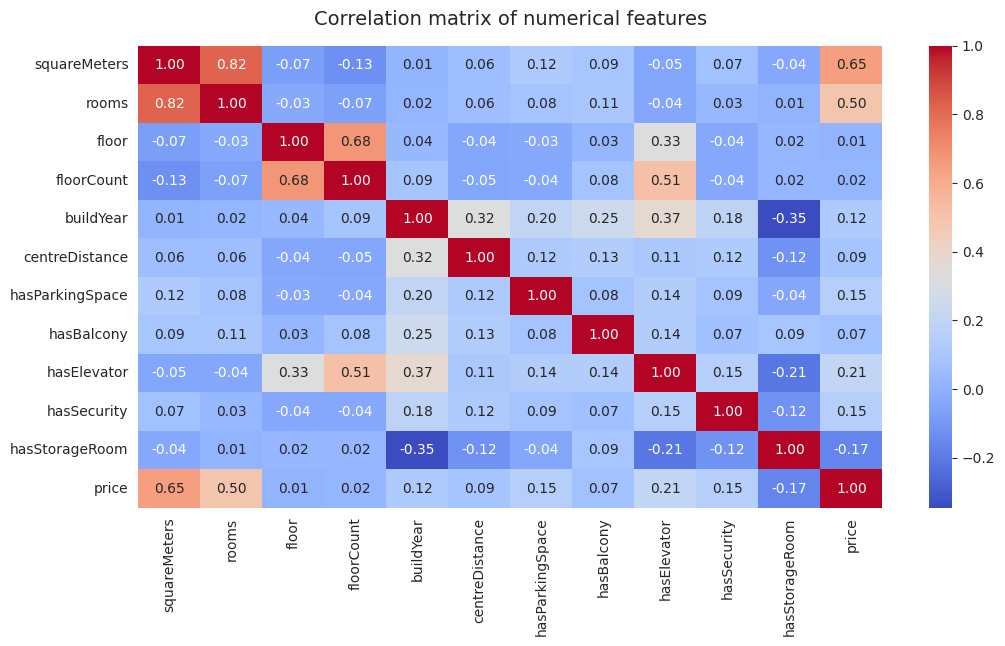

In [17]:
plt.figure(figsize=(12, 6))
corr_matrix = train.corr(numeric_only=True).drop(columns=['latitude', 'longitude'], index=['latitude', 'longitude'])
plt.title("Correlation matrix of numerical features", fontsize=14, pad=15)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True,fmt=".2f")
plt.show()

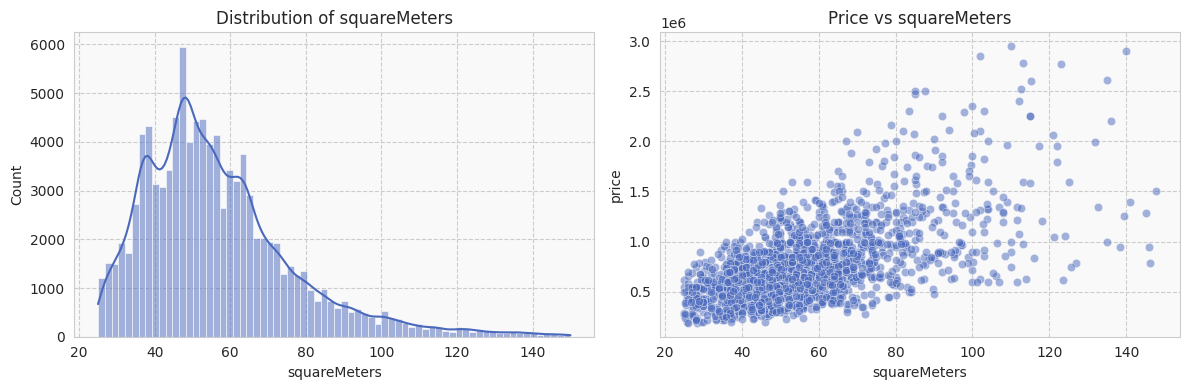

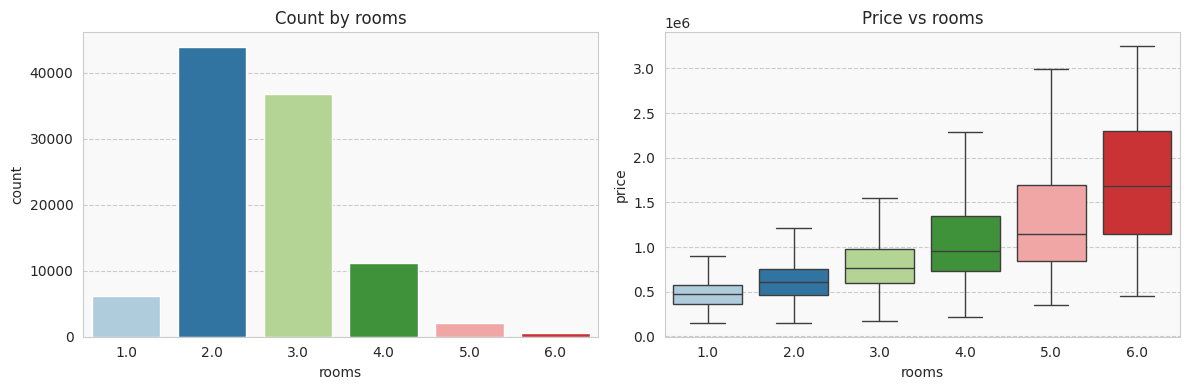

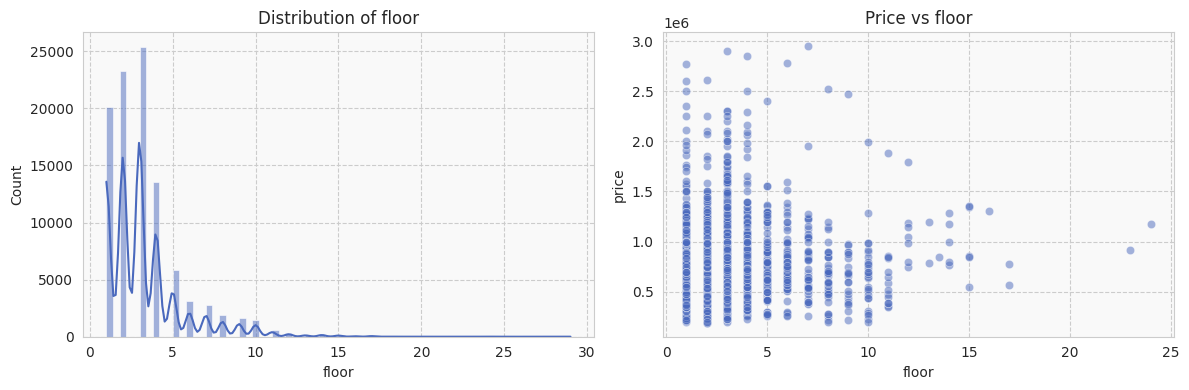

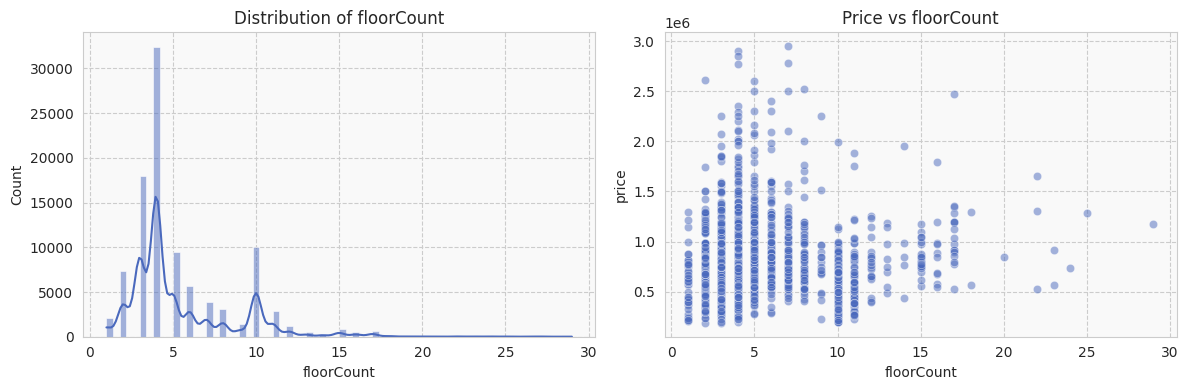

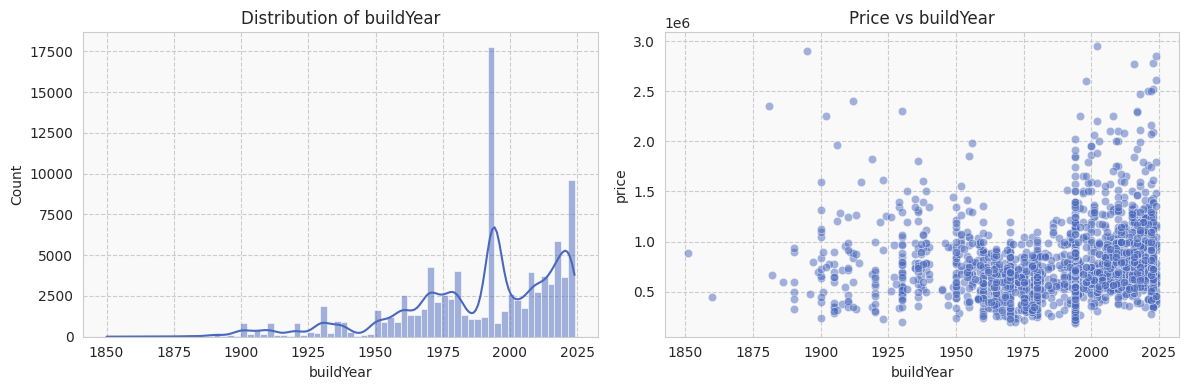

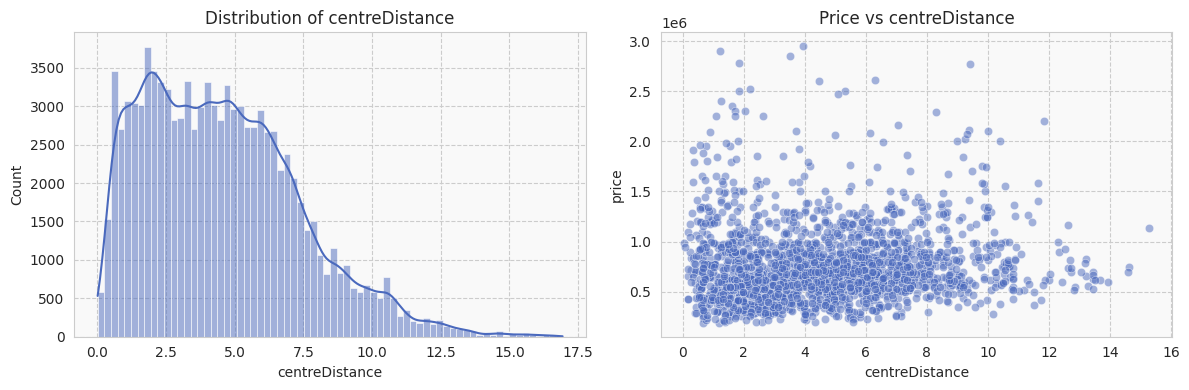

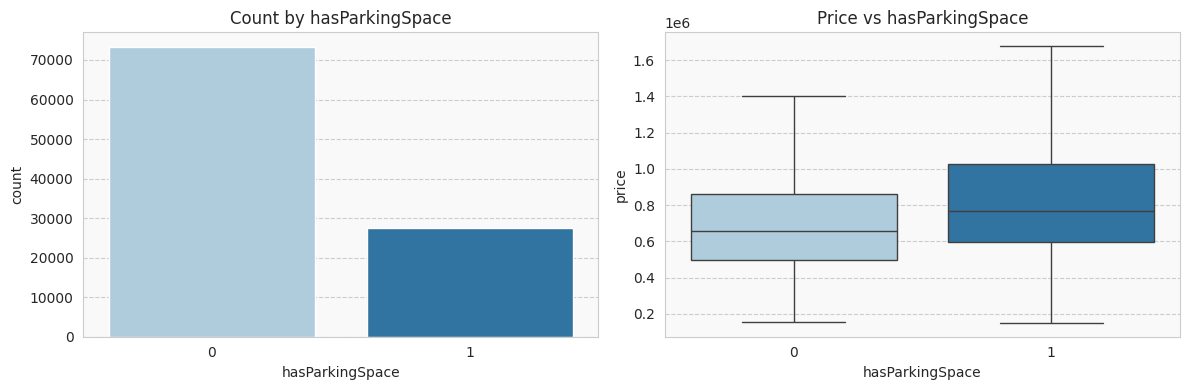

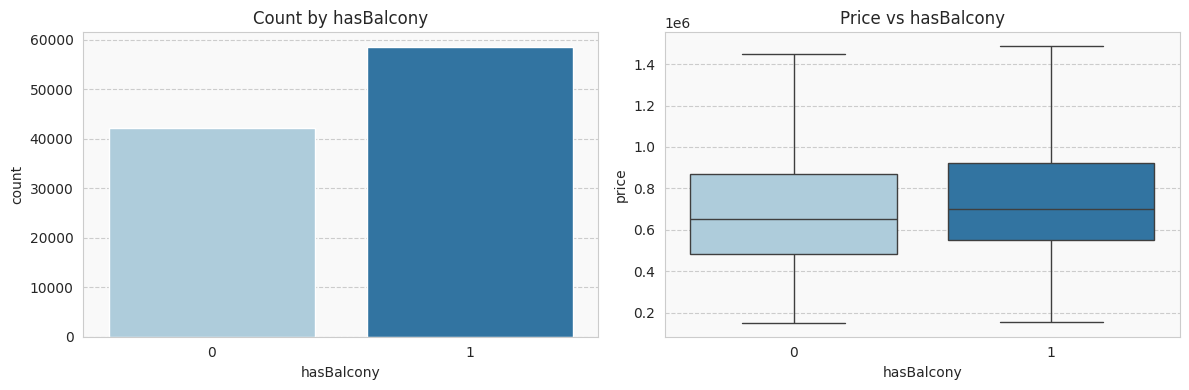

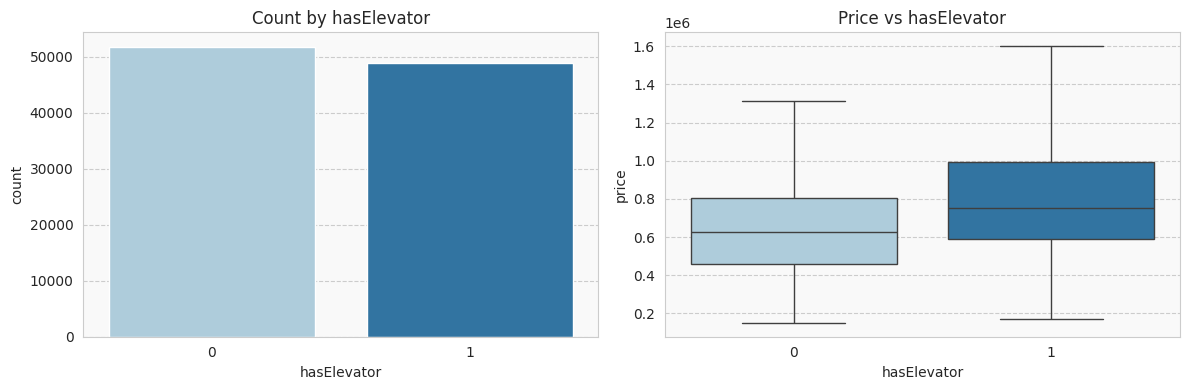

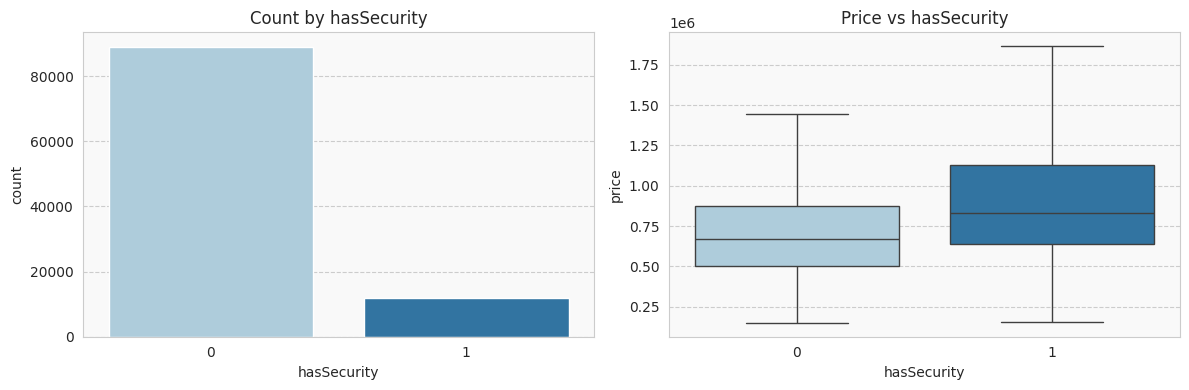

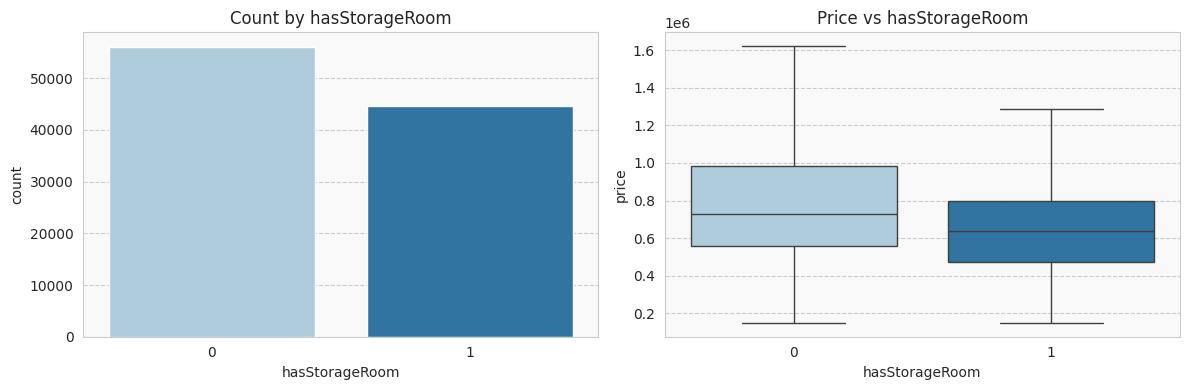

In [18]:
num_cols = train.select_dtypes(exclude='object').columns.drop(['price','latitude','longitude'])
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if col in ['squareMeters','buildYear','centreDistance','floor','floorCount']:
        sns.histplot(train, x=col, kde=True, ax=axes[0], bins=70, color=color, edgecolor='white')
        axes[0].set_title(f'Distribution of {col}')
        sns.scatterplot(train.sample(2000,random_state=42), x=col, y='price',color=color,ax=axes[1],alpha=0.5)
        axes[1].set_title(f'Price vs {col}')
    else:
        sns.countplot(train, x=col, ax=axes[0], palette='Paired', edgecolor='white')
        axes[0].set_title(f'Count by {col}')
        sns.boxplot(train,x=col,y='price',palette='Paired',showfliers=False)
        axes[1].set_title(f'Price vs {col}')
    plt.tight_layout()
    plt.show()

### Insights
Based on the distribution analysis, I implement **clipping** to stabilize the features and focus the model on the typical housing segment:

**floor & floorCount (0–15):** High rise buildings (above 15 floors) are rare in the dataset. By capping these values at 15, all of them are grouped into a single category, reducing the impact of extreme outliers while maintaining the structural information.

**buildYear >1900:** Properties built before 1900 are often historical tenements with similar valuation characteristics. Clipping the minimum year to 1900 simplifies the timeline for the model.

I also change the plots types for **floor** and **floorCount** to countplot and boxplot.

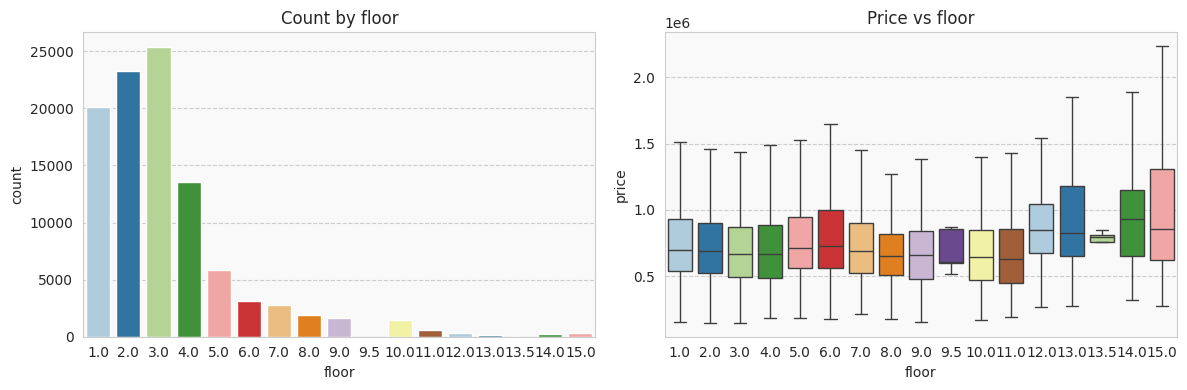

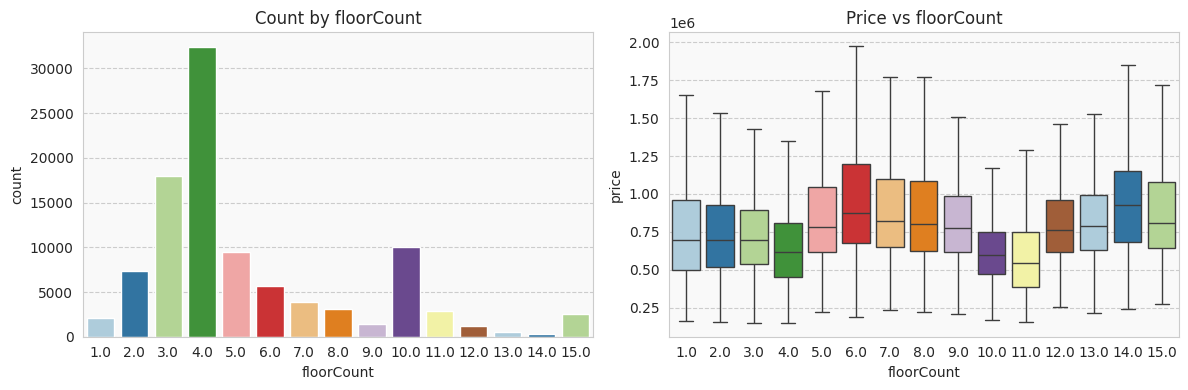

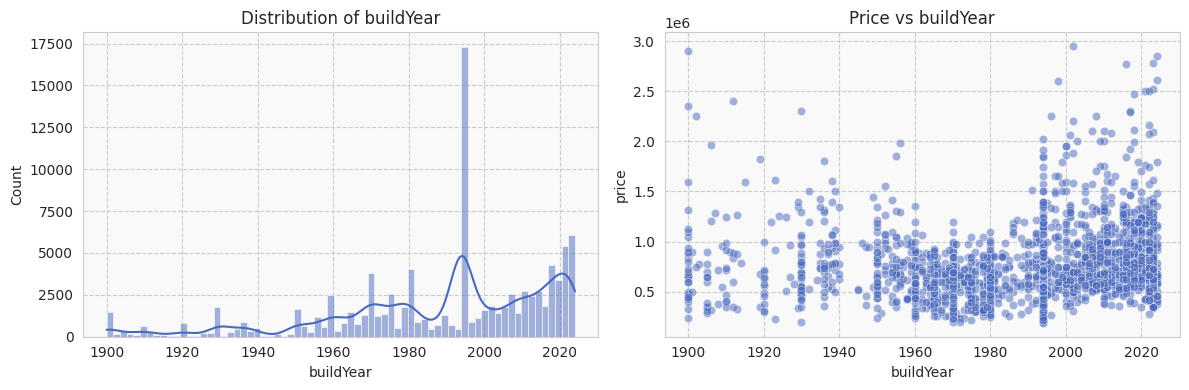

In [19]:
train['floor'] = train['floor'].clip(upper=15)
train['floorCount'] = train['floorCount'].clip(upper=15)
train['buildYear'] = train['buildYear'].clip(lower=1900)
clipped = ['floor','floorCount','buildYear']
for col in clipped:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if col in ['buildYear']:
        sns.histplot(train, x=col, kde=True, ax=axes[0], bins=70, color=color, edgecolor='white')
        axes[0].set_title(f'Distribution of {col}')
        sns.scatterplot(train.sample(2000,random_state=42), x=col, y='price',color=color,ax=axes[1],alpha=0.5)
        axes[1].set_title(f'Price vs {col}')
    else:
        sns.countplot(train, x=col, ax=axes[0], palette='Paired', edgecolor='white')
        axes[0].set_title(f'Count by {col}')
        order_price = train.groupby(col)['price'].median().sort_values(ascending=False).index
        sns.boxplot(train,x=col,y='price',palette='Paired',showfliers=False,ax=axes[1])
        axes[1].set_title(f'Price vs {col}')
    plt.tight_layout()
    plt.show()

# 🏷️Categorical features analysis

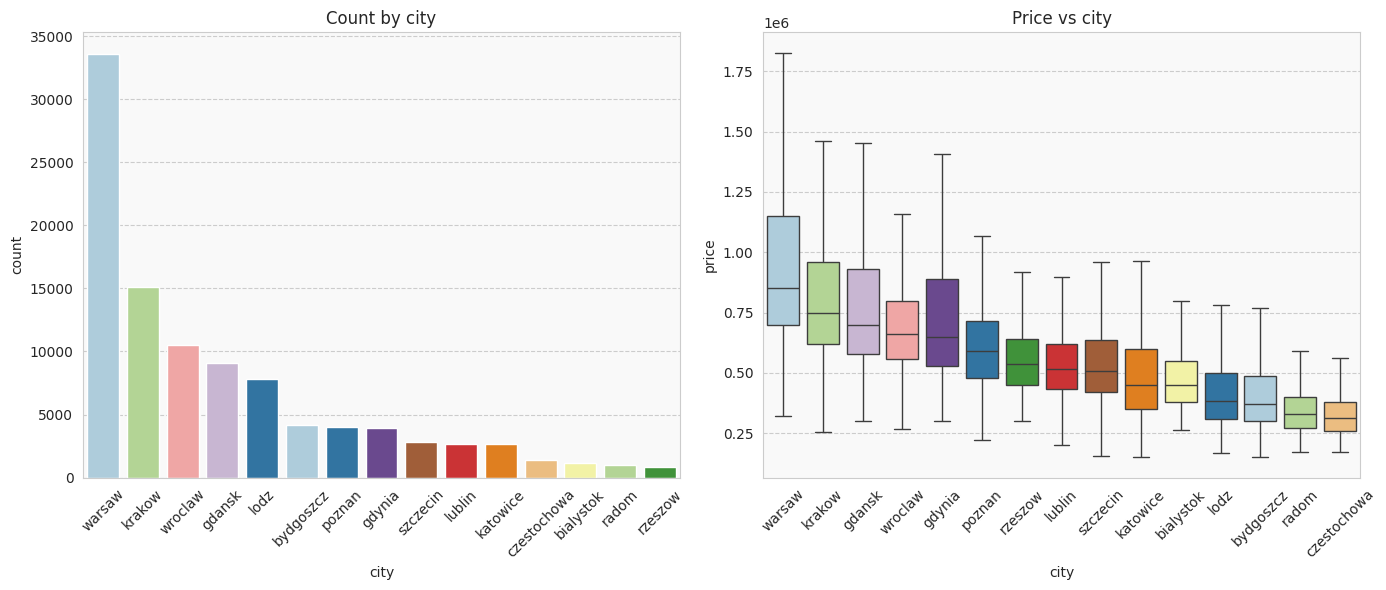

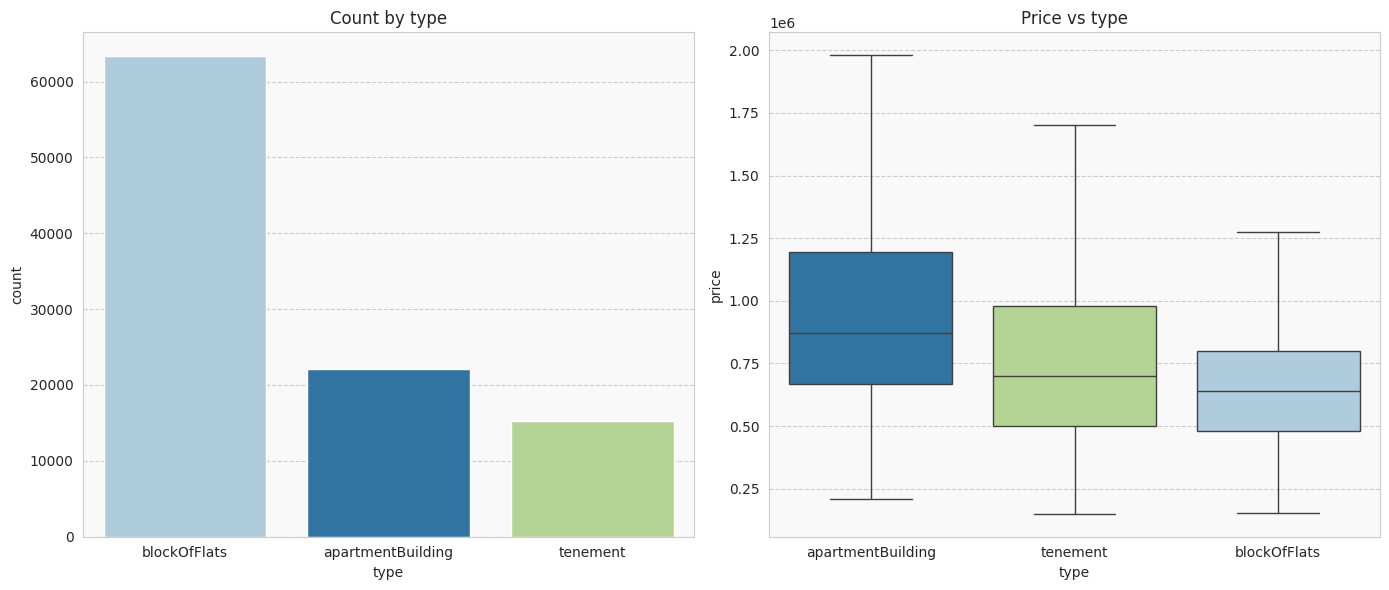

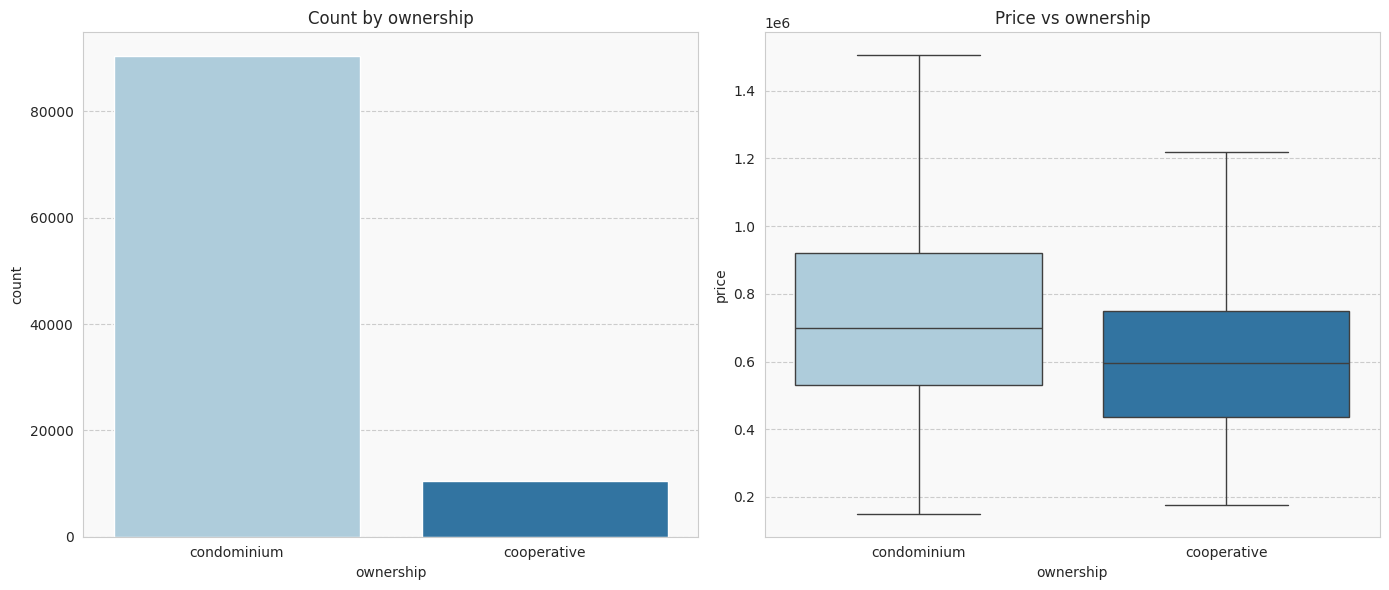

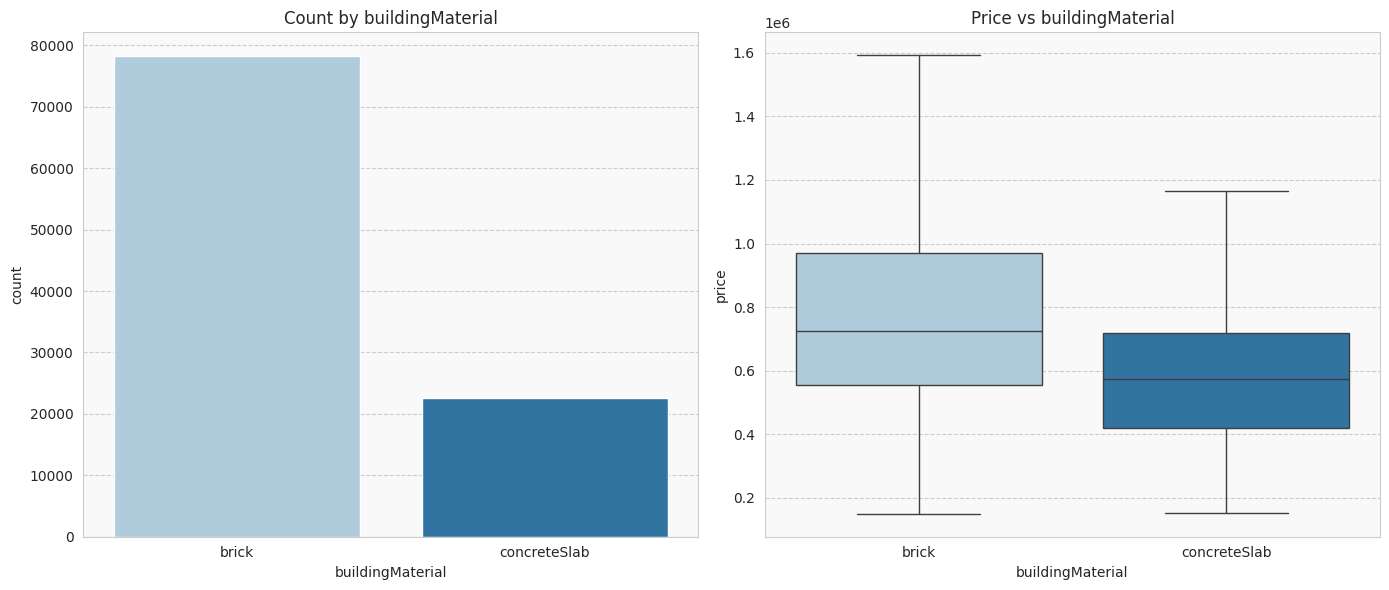

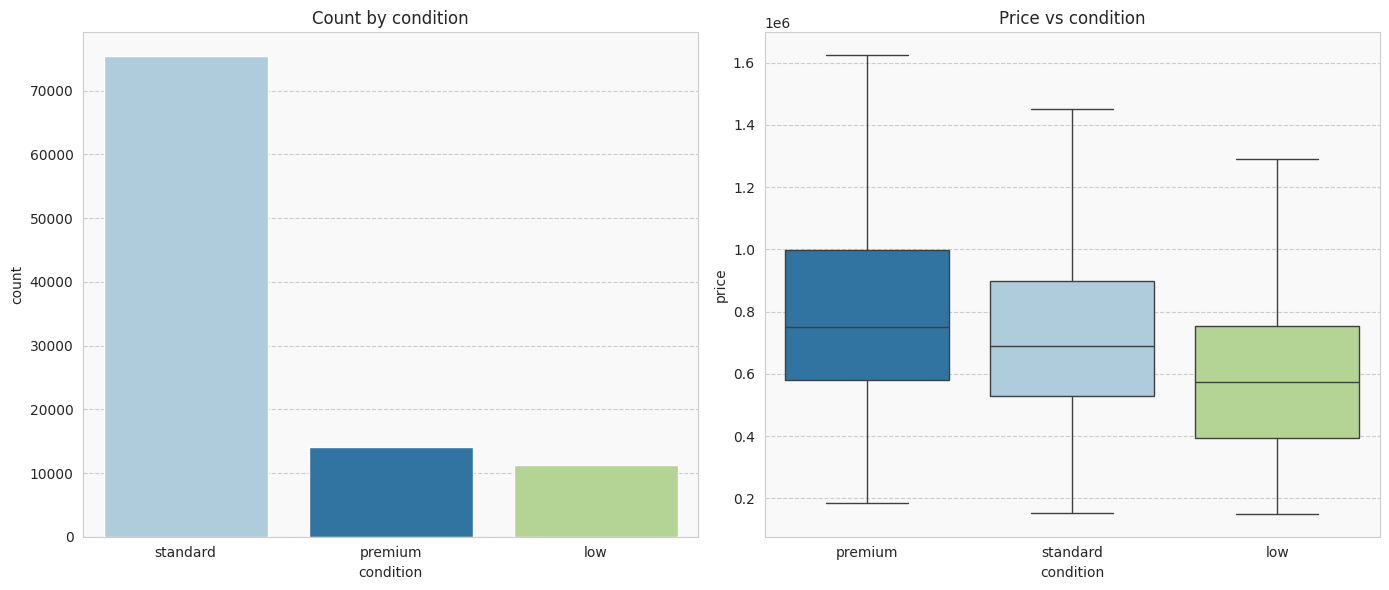

In [20]:
cat_cols = train.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    unique= train[col].unique()
    palette_colors = sns.color_palette('Paired', n_colors=len(unique))
    color_map = dict(zip(unique, palette_colors))

    order_counts = train[col].value_counts().index
    sns.countplot(data=train, x=col, ax=axes[0], palette=color_map, edgecolor='white', order=order_counts)
    axes[0].set_title(f'Count by {col}')

    order_price = train.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=train, x=col, y='price', palette=color_map, showfliers=False, ax=axes[1], order=order_price)
    axes[1].set_title(f'Price vs {col}')
    if col=='city':
        axes[0].tick_params(axis='x',rotation=45)
        axes[1].tick_params(axis='x',rotation=45)
    
    plt.tight_layout()
    plt.show()

# 🎯 Target variable
As shown earlier, the **price** distribution is significantly right skewed. I apply logarithmic transformation **(ln(1+x))**  to the target variable, to normalize the distribution. I will conduct a comparison of training the models on both the raw and transformed target variables, to determine which approach gives a lower error rate and better generalization

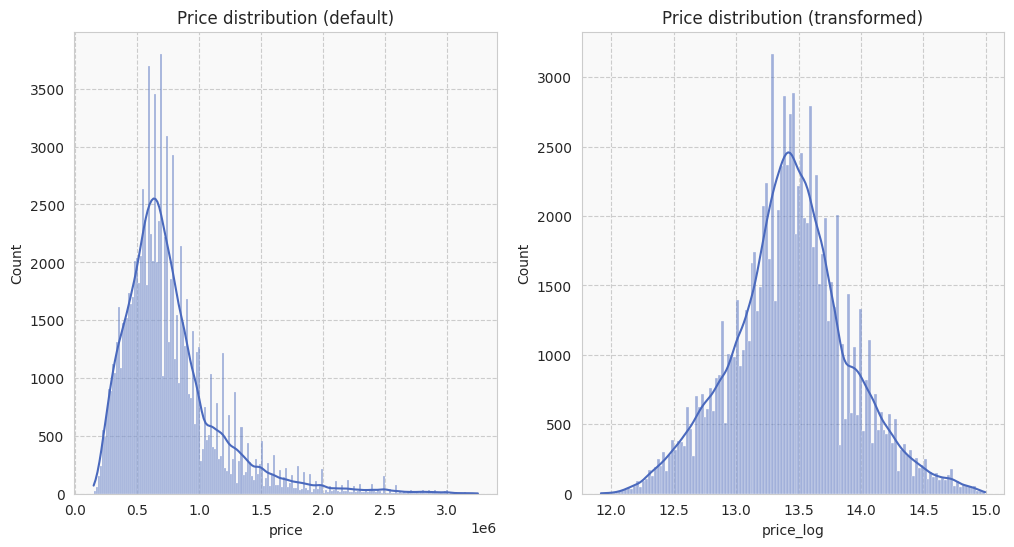

Mean test set price: 768675.57 PLN


In [21]:
train['price_log']=np.log1p(train['price'])
fig,axes = plt.subplots(1,2,figsize=(12,6))
sns.histplot(train,x='price',kde=True,color=color,ax=axes[0])
axes[0].set_title('Price distribution (default)')

sns.histplot(train,x='price_log',kde=True,color=color,ax=axes[1])
axes[1].set_title('Price distribution (transformed)')
plt.show()
print(f'Mean test set price: {round(train['price'].mean(),2)} PLN')

## Overall observations & Model selection
Based on the distribution of features and their influence on the target variable, I decided to use tree based models **RandomForestRegressor** and **XGBRegressor** as the primary algorithms for this task. I chose these over classic **LinearRegression** due to:

**Multicollinearity:** tree-based models naturally handle correlated variables like `squareMeters` and `rooms` without losing stability.

**Non linear dependencies:** the housing market may contain non linear relationships that decision trees can spot through hierarchical splitting.

**Scaling:** trees algorithms do not require scaling techniques for the numerical features which makes pipeline simpler.

While **LinearRegression** offers straightforward interpretability, the primary objective of this project is to maximize predictive accuracy by minimizing **mean squared error** and **mean absiolute error**. Considering data srructure, here ensemble tree methods are better for meeting these requirements. To bridge the gap between performance and transparency, I will employ SHAP, ensuring the model remains both powerful and explainable

# 🔄 Data preprocessing
## Cleaning function
I begin with defining a **cleaner** function which contains every change performed earlier on the train set. The logic for data imputation stays the same.

**Future improvement**: In the next iterations of this project, I plan to refactor this step by implementing Custom Transformers. This will allow the scikit-learn Pipeline to automatically remember these training values, eliminating the need to manually copy the dictionary into the deployment code.

In [22]:
imput_values = {}
for col in train.columns.drop(['price','price_log','latitude','longitude']):
    if train[col].dtype == np.number:
        imput_values[col] = train[col].median()
    else:
        imput_values[col] = train[col].mode()[0]
print('Calculated values from train: ')
print(imput_values)

Calculated values from train: 
{'city': 'warsaw', 'type': 'blockOfFlats', 'squareMeters': 53.0, 'rooms': 3.0, 'floor': 3.0, 'floorCount': 4.0, 'buildYear': 1994.0, 'centreDistance': 4.23, 'ownership': 'condominium', 'buildingMaterial': 'brick', 'condition': 'standard', 'hasParkingSpace': np.int8(0), 'hasBalcony': np.int8(1), 'hasElevator': np.int8(0), 'hasSecurity': np.int8(0), 'hasStorageRoom': np.int8(0)}


In [23]:
def cleaner(data):
    df = data.copy()
    for col in ['floorCount', 'buildYear']:
        if col in df.columns:
            df[col] = df[col].fillna(imput_values[col])
    
    if 'floor' in df.columns and 'floorCount' in df.columns:
        df['floorCount'] =df[['floor', 'floorCount']].max(axis=1)
        
    
    if 'hasElevator' in df.columns and 'buildYear' in df.columns and 'floorCount' in df.columns:
        mask_elevator = (df['buildYear'] >= 1980) & (df['floorCount'] >= 5)
        df['hasElevator'] = df['hasElevator'].fillna(mask_elevator.astype('float64'))
        
    if 'floor' in df.columns and 'floorCount' in df.columns:
        df['floor'] = df['floor'].fillna(df['floorCount'].map(floor_median))
        if 'floor' in imput_values:
            df['floor'] = df['floor'].fillna(imput_values['floor'])

    
    def fill_type(row):
        if pd.isnull(row['type']):
            year = row['buildYear']
            
            if year < 1960: 
                return 'tenement'
            elif year < 2010: 
                return 'blockOfFlats'
            else: 
                return 'apartmentBuilding'
        return row['type']
            
    if 'type' in df.columns and 'buildYear' in df.columns:
        df['type']= df.apply(fill_type, axis=1)

    
    def fill_material(row):
        if pd.isnull(row['buildingMaterial']):
            year = row['buildYear']
            b_type = row['type']
            if pd.isnull(year) or pd.isnull(b_type):
                return 'brick'
            if b_type == 'tenement': 
                return 'brick'   
            if year < 1970: 
                return 'brick'
            if b_type == 'blockOfFlats' and 1970<= year <=  1990: 
                return 'concreteSlab'
            if year > 1990: 
                return 'brick'
            return 'brick'
        else:
            return row['buildingMaterial']

    if 'buildingMaterial' in df.columns and 'buildYear' in df.columns and 'type' in df.columns:
        df['buildingMaterial'] = df.apply(fill_material, axis=1)
        
    
    if 'floor' in df.columns:
        df['floor'] = df['floor'].clip(upper=15)
    if 'floorCount' in df.columns:
        df['floorCount'] = df['floorCount'].clip(upper=15)
    if 'buildYear' in df.columns:
        df['buildYear']= df['buildYear'].clip(lower=1900)
    if 'ownership' in df.columns:
        df = df.loc[df['ownership'] != 'udział']
        
    for col in df.columns:
        if col in imput_values:
            df[col] = df[col].fillna(imput_values[col])

    return df

## Encoding strategy
**OneHotEncoder**: `type`, `ownership`,`building_material`

These features have a low cardinality and no logical order. OHE allows the model to treat each category independently without assuming any ranking between them.

**OrdinalEncoder**: `condition`

This feature represents a clear hierarchy of apartment standards which I want to preserve. I map as following (0-low, 1-standard, 2-premium).

**TargetEncoder**:  `city`

While 15 cities could be handled by OHE, I chose target encoding to capture the relationship between location and the average price. To prevent overfitting for cities with fewer records, I use smoothing.

In [24]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,TargetEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor

to_ohe = ['type','ownership','buildingMaterial']
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop=None)

to_ordinal = ['condition']
type_categories = [['low','standard','premium']]
ordinal_enc = OrdinalEncoder(categories=type_categories)

to_target = ['city']
target_enc = TargetEncoder(smooth='auto', target_type='continuous')

preprocessor = ColumnTransformer(transformers=[
    ('ohe',ohe,to_ohe),
    ('ordinal',ordinal_enc,to_ordinal),
    ('target',target_enc,to_target)
],remainder='passthrough')


# Baseline models comparison
In this section I perform a comparision between **DecisionTree**, **RandomForest** and **XGBRegressor**. To compare them I use such metrics:

**Mean absolute error (MAE):**  as the name suggests, this metric helps determine the average absolute difference between the predicted and real prices. A raw number doesn't indicate much (a MAE of 50k would be poor for a dataset with prices from 100k-200k, but good for properties over 500k). To counter this scale dependency, I calculate the **mean absolute percentage error (MAPE)**. If the MAPE is around 10%, I can assume the model has strong predictive power. 

**Root mean squared error (RMSE):** this metric helps determine whether the model committed significant outlier errors. It usually happens when the dataset is highly diverse, containing cheap and expensive properties. Similar to MAE, the raw RMSE value doesn't provide much information. I calculate the **relative RMSE  (RMSE / mean price)**,) to compare it with **MAPE**. Aiming for a small gap between these two.

**R squared:** assistant metric used to measure the overall predictive power and indicate the proportion of variance in the target variable that the model explains.

I use 5 fold cross validation to ensure that there is no overfitting.

In [25]:
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

models = {
    'DecisionTreeRegressor': DecisionTreeRegressor(
        random_state=42,
    ),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),
    'XGBRegressor': XGBRegressor(
        n_estimators=200,          
        random_state=42,
    )
}

metrics = {
        'mae': 'neg_mean_absolute_error',
        'mse': 'neg_mean_squared_error',
        'mape': 'neg_mean_absolute_percentage_error',
        'r2': 'r2'
    }

y_mean = y_train.mean()

for name, model in models.items():
    print(f'\n\nModel: {name}')
    steps = [
        ('cleaner',FunctionTransformer(cleaner)),
        ('preprocessor', preprocessor),
        ('model', model) 
    ]
  
    pipe=Pipeline(steps)
    cv=cross_validate(pipe, X_train, y_train, scoring=metrics, cv=5, n_jobs=-1)
    mae = -cv['test_mae'].mean()
    mse = -cv['test_mse'].mean()
    rmse = np.sqrt(mse)
    mape = -cv['test_mape'].mean()*100 
    mae_std = cv['test_mae'].std()
    rmse_ratio = (rmse/y_mean)*100
    r2 = cv['test_r2'].mean()
    
    print("\nScores on 5 fold cross validation (basic price):")
    print(f"MAE: {round(mae, 2)} PLN, MAPE: {round(mape, 2)}%")
    print(f"RMSE: {round(rmse, 2)} PLN, relative RMSE: {round(rmse_ratio, 2)}%")
    print(f"R squared: {round(r2, 2)} ")

    model_log = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )

    pipe_log = Pipeline([
        ('cleaner', FunctionTransformer(cleaner)),
        ('preprocessor', preprocessor),
        ('model', model_log)
    ])

    cv_log = cross_validate(pipe_log, X_train, y_train, scoring=metrics, cv=5, n_jobs=-1)
    mae_log = -cv_log['test_mae'].mean()
    mse_log = -cv_log['test_mse'].mean()
    rmse_log = np.sqrt(mse_log)
    mape_log = -cv_log['test_mape'].mean()*100
    rmse_ratio_log = (rmse_log/y_mean)*100
    r2_log = cv_log['test_r2'].mean()

    print("\nScores on 5 fold cross validation (log price):")
    print(f"MAE: {round(mae_log, 2)} PLN, MAPE: {round(mape_log, 2)}%")
    print(f"RMSE: {round(rmse_log, 2)} PLN, relative RMSE: {round(rmse_ratio_log, 2)}%")
    print(f"R squared: {round(r2_log, 2)}")



Model: DecisionTreeRegressor

Scores on 5 fold cross validation (basic price):
MAE: 89064.82 PLN, MAPE: 11.55%
RMSE: 164422.87 PLN, relative RMSE: 21.39%
R squared: 0.83 

Scores on 5 fold cross validation (log price):
MAE: 88856.3 PLN, MAPE: 11.54%
RMSE: 164949.49 PLN, relative RMSE: 21.46%
R squared: 0.83


Model: RandomForestRegressor

Scores on 5 fold cross validation (basic price):
MAE: 72771.79 PLN, MAPE: 9.43%
RMSE: 121796.98 PLN, relative RMSE: 15.85%
R squared: 0.91 

Scores on 5 fold cross validation (log price):
MAE: 72264.29 PLN, MAPE: 9.21%
RMSE: 121640.01 PLN, relative RMSE: 15.82%
R squared: 0.91


Model: XGBRegressor

Scores on 5 fold cross validation (basic price):
MAE: 90127.14 PLN, MAPE: 11.75%
RMSE: 136655.94 PLN, relative RMSE: 17.78%
R squared: 0.88 

Scores on 5 fold cross validation (log price):
MAE: 89298.85 PLN, MAPE: 11.29%
RMSE: 138505.99 PLN, relative RMSE: 18.02%
R squared: 0.88


## Observation & strategy
**RandomForest** outperformed the other two models, showing really promising results. However, comparing only baseline models naturally favors this algorithm due to its strong out of the box performance. To ensure a fair comparison, I will also tune the hyperparameters of the **XGBRegressor**, as gradient boosting models require tuning to unlock their full potential. After optimizing both models, I will compare their final scores to chose the winning algorithm.

**Target transofrmation:** transforming the price didn't result in a significant enough improvement in the metrics to justify the added complexity. Following the principle of simplicity, it is better to avoid the need of transforming and inverse transforming the predictions just to get the price back in PLN. Therefore, I choose to proceed with the raw target variable.

# Hyperparameter tuning
## Random Forest
Random Forest provides a very solid baseline right from the start and is less sensitive to hyperparameter changes. To balance accuracy gains with computational efficiency, I restrict the optuna search to just 20 trials.

In [ ]:
%%capture
  
import optuna
from optuna.integration import OptunaSearchCV

rf_pipe = Pipeline(steps=[
    ('cleaner', FunctionTransformer(cleaner)),
    ('preprocessor', preprocessor),
    ('model', models['RandomForestRegressor'])
])

rf_params = {
    'model__n_estimators': optuna.distributions.IntDistribution(200, 500, step=100),
    'model__max_depth': optuna.distributions.IntDistribution(10, 40),  
    'model__min_samples_split': optuna.distributions.IntDistribution(2, 10),
    'model__min_samples_leaf': optuna.distributions.IntDistribution(1, 4),
    'model__max_features': optuna.distributions.FloatDistribution(0.5, 1.0), 
}

rf_search = OptunaSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_params,
    n_trials=20,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=1 
)

rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_

In [28]:
print(f"Best Random forest params {rf_search.best_params_}")

cv_rf = cross_validate(rf_model, X_train, y_train, scoring=metrics, cv=5, n_jobs=-1)
mae = -cv_rf['test_mae'].mean()
mse = -cv_rf['test_mse'].mean()
rmse = np.sqrt(mse)
mape = -cv_rf['test_mape'].mean() * 100
rmse_ratio = (rmse / y_mean) * 100
r2 = cv_rf['test_r2'].mean()

print("\nScores on 5-fold cross validation (Random Forest tuned):")
print(f"MAE: {round(mae, 2)}, MAPE: {round(mape, 2)}%")
print(f"RMSE: {round(rmse, 2)}, relative RMSE: {round(rmse_ratio, 2)}%")
print(f"R squared: {round(r2, 2)}")

Best Random forest params {'model__n_estimators': 500, 'model__max_depth': 30, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 0.9943277905108943}

Scores on 5-fold cross validation (Random Forest tuned):
MAE: 73812.69, MAPE: 9.56%
RMSE: 122492.98, relative RMSE: 15.94%
R squared: 0.9


**Tuned RandomForest** perfmored lightly worse than its baseline version. It may seem like an error or a flaw in the tuning process, but it is actually quite standard for this specific algorithm. Random Forests generally provide peak performance with their default hyperparameters, and their tuning often just acts as an additional regularization layer rather than a performance booster.

## XGBRegressor
For the XGBoost model, I increased the number of Optuna trials to 45. Since XGBoost trains significantly faster than Random Forest in this setup

In [29]:
%%capture 
import optuna
from optuna.integration import OptunaSearchCV
xgb_pipe = Pipeline(steps=[
    ('cleaner', FunctionTransformer(cleaner)),
    ('preprocessor', preprocessor),
    ('model', models['XGBRegressor'])
])

xgb_params = {
    'model__n_estimators': optuna.distributions.IntDistribution(1000, 2000, step=100),
    'model__learning_rate': optuna.distributions.FloatDistribution(0.01, 0.1, log=True),
    'model__max_depth': optuna.distributions.IntDistribution(6, 16),
    'model__min_child_weight': optuna.distributions.IntDistribution(1, 10),
    'model__subsample': optuna.distributions.FloatDistribution(0.7, 1.0),
    'model__colsample_bytree': optuna.distributions.FloatDistribution(0.7, 1.0)
}

xgb_search = OptunaSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_params,
    n_trials=50,
    scoring='neg_mean_absolute_error',
    cv=3,
    random_state=42,
    verbose=1,
    n_jobs=1 
)

xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_

In [30]:
print(f"Best params: {xgb_search.best_params_}")
cv_xgb = cross_validate(xgb_model, X_train, y_train, scoring=metrics, cv=5, n_jobs=-1)
mae = -cv_xgb['test_mae'].mean()
mse = -cv_xgb['test_mse'].mean()
rmse = np.sqrt(mse)
mape = -cv_xgb['test_mape'].mean() * 100
rmse_ratio = (rmse / y_mean) * 100
r2 = cv_xgb['test_r2'].mean()

print("\nScores on 5-fold cross validation (XGBREgressor tuned):")
print(f"MAE: {round(mae, 2)} PLN, MAPE: {round(mape, 2)}%")
print(f"RMSE: {round(rmse, 2)}PLN, relative RMSE: {round(rmse_ratio, 2)}%")
print(f"R squared: {round(r2, 2)})")

Best params: {'model__n_estimators': 1800, 'model__learning_rate': 0.01973716947362824, 'model__max_depth': 16, 'model__min_child_weight': 3, 'model__subsample': 0.7868481988521261, 'model__colsample_bytree': 0.9355371302877797}

Scores on 5-fold cross validation (XGBREgressor tuned):
MAE: 67987.45 PLN, MAPE: 8.87%
RMSE: 116191.35PLN, relative RMSE: 15.12%
R squared: 0.91)


**Tuned XGBRegressor** outperformed all previous models, achieving the best overall metrics. Therefore, I select it as the final model for this project. Now, I will perform a final evaluation on the unseen test set to confirm its generalization capabilities and ensure there is no overfitting.

# 📝 Final model evaluation

In [31]:
xgb_model.fit(X_train,y_train)
preds = xgb_model.predict(X_test)
y_mean = y_test.mean()
mae = mean_absolute_error(y_test, preds)
mape = mean_absolute_percentage_error(y_test, preds) * 100  
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
relative_rmse = (rmse/y_mean) * 100


print("Scores on test set: ")
print(f"MAE: {mae:.2f} PLN, MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f} PLN, Relative RMSE: {relative_rmse:.2f}%")


Scores on test set: 
MAE: 63192.79 PLN, MAPE: 8.31%
RMSE: 108063.17 PLN, Relative RMSE: 14.11%


Interestingly, the results on **test set** are slightly better than those obtained during cross validation. This suggests that the final model benefited from being trained on the full training dataset, leading to improved generalization without overfitting.

## Comparison of predicted and actual prices 

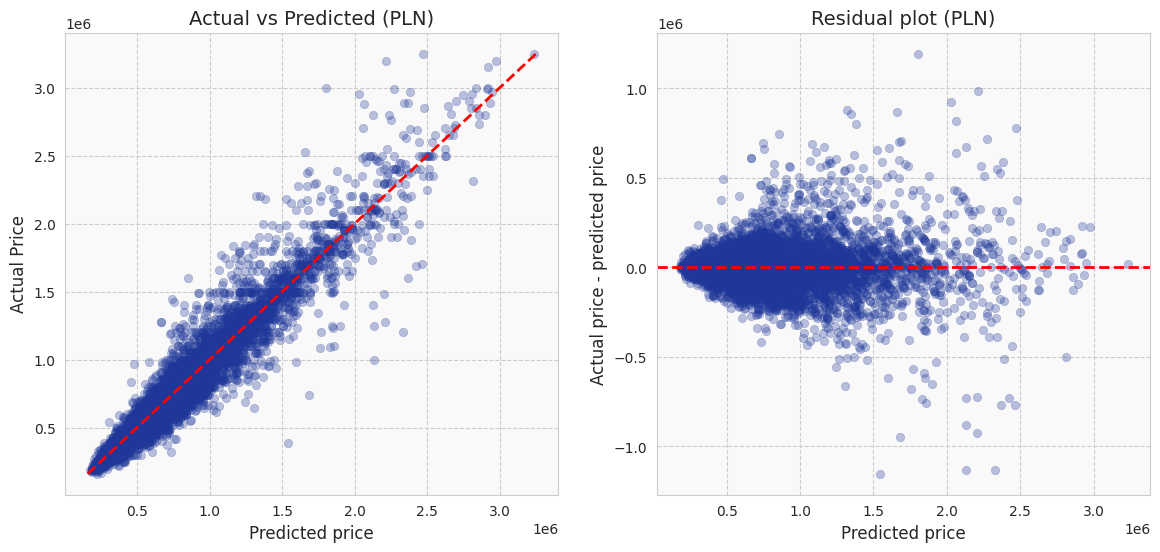

In [32]:
fig,axes = plt.subplots(1,2,figsize=(14,6))
sns.scatterplot(x=preds, y=y_test, alpha=0.3, color="#1e3799", edgecolor=None, ax=axes[0])
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted price', fontsize=12)
axes[0].set_ylabel('Actual Price', fontsize=12)
axes[0].set_title('Actual vs Predicted (PLN)', fontsize=14)

residuals = y_test - preds
sns.scatterplot(x=preds, y=residuals, alpha=0.3, color="#1e3799", edgecolor=None,ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted price', fontsize=12)
axes[1].set_ylabel('Actual price - predicted price', fontsize=12)
axes[1].set_title('Residual plot (PLN)', fontsize=14)
plt.show()

These plots show that the model is **generally trustworthy** and captures the main pricing trends well. It is very accurate for typical apartments, however, as the residual plot indicates, the variance of errors increases for more expensive properties. This heteroscedasticity is typical for the housing market, as the value of premium properties is often driven by unmeasured factors like prestige or historical significance, not just standard physcial features.

## Feature importances

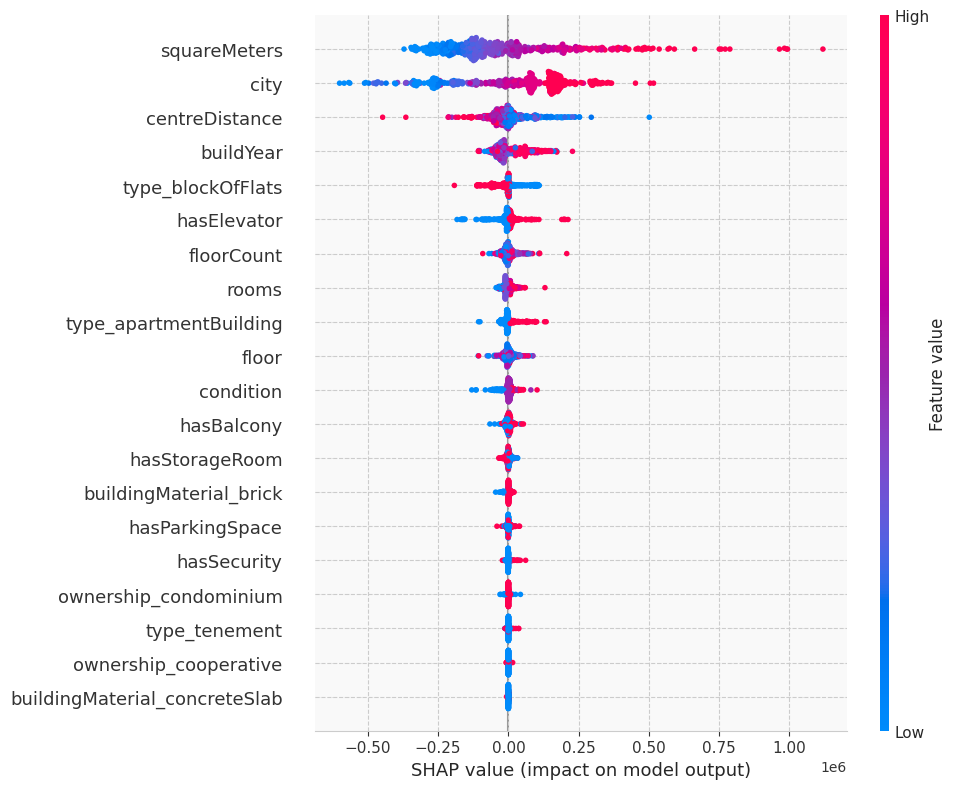

In [33]:
import shap
X_test_clean = xgb_model.named_steps['cleaner'].transform(X_test)
X_test_transformed = xgb_model.named_steps['preprocessor'].transform(X_test_clean)


if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
names=[]
for name in feature_names:
    name = name.split('__')[1]
    names.append(name)
model = xgb_model.named_steps['model']


explainer = shap.TreeExplainer(model)


X_test_sample = shap.utils.sample(X_test_transformed, nsamples=500, random_state=42)

shap_values = explainer.shap_values(X_test_sample, approximate=True, check_additivity=False)
shap.summary_plot(shap_values, X_test_sample, feature_names=names, plot_size=(10, 8))

# 💾 Saving data

In [34]:
X_full= pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)

X_bi = xgb_model.named_steps['cleaner'].transform(X_full)
preds = xgb_model.predict(X_full)

df_bi = X_bi.copy()
df_bi['Price_actual']=y_full
df_bi['Price_predicted'] = np.round(preds, 2)
df_bi['PA_difference'] = df_bi['Price_predicted']-df_bi['Price_actual']

df_bi['latitude'] = data.loc[df_bi.index, 'latitude']
df_bi['longitude'] = data.loc[df_bi.index, 'longitude']
df_bi = df_bi.reset_index().rename(columns={'index': 'offer_id'})
df_bi.to_csv('housing_bi.csv', index=False)